## **Importing Libraries**

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
credit_risk_df = pd.read_csv("credit_risk_dataset.csv")

# **Exploratory Data Analysis(EDA)**

In [5]:
credit_risk_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
credit_risk_df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [7]:
credit_risk_df.shape

(32581, 12)

In [8]:
credit_risk_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
credit_risk_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [10]:
credit_risk_df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [11]:
credit_risk_df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

In [12]:
credit_risk_df.loan_status.value_counts().reset_index()

,loan_status,count
0,0,25473
1,1,7108


In [13]:
print(f"Total duplicate samples: {credit_risk_df.duplicated().sum()}")

Total duplicate samples: 165


In [14]:
# Lets See the Correlation between the columns

confusion_mat = credit_risk_df.corr(numeric_only=True)
confusion_mat

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


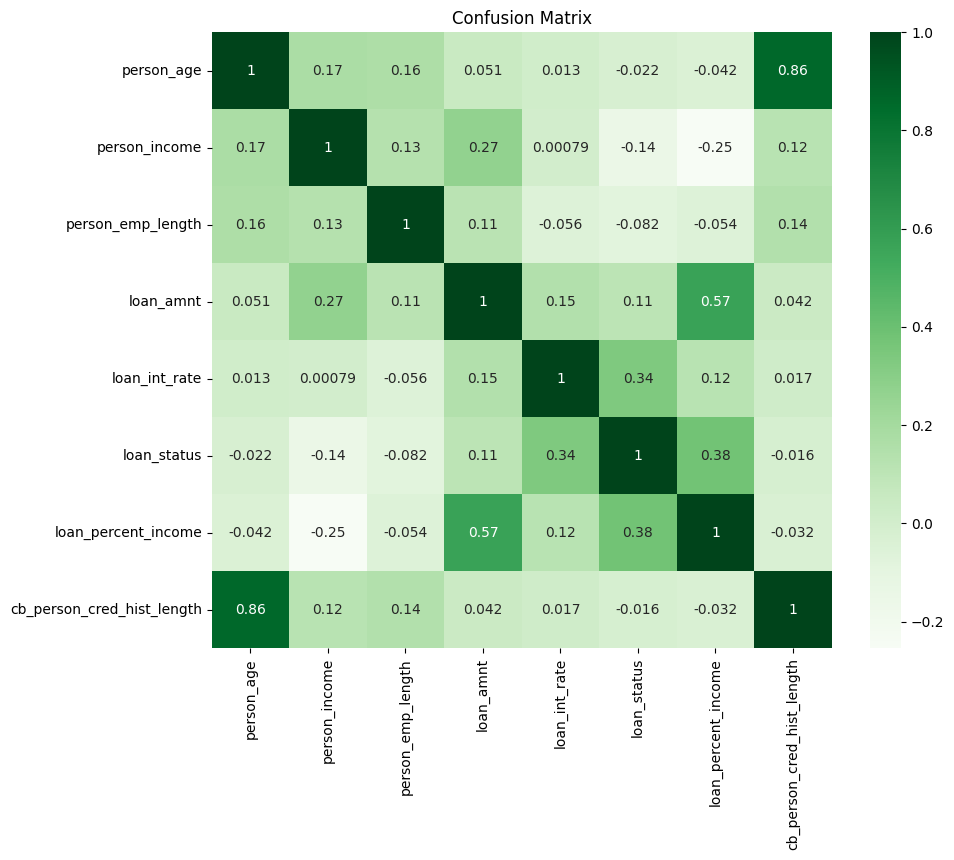

In [15]:
# Plot for Confusion Matrix
plt.figure(figsize=(10,8))
sns.heatmap(confusion_mat, annot=True, cmap="Greens")
plt.title("Confusion Matrix")
plt.show()

In [16]:
# Count of unique values for the categorical features:
categorical_cols = credit_risk_df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    print(f"\n\n\n--- {col} ---")
    print(credit_risk_df[col].value_counts())




--- person_home_ownership ---
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64



--- loan_intent ---
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64



--- loan_grade ---
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64



--- cb_person_default_on_file ---
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


/var/folders/_2/jpmfdqtd00jd3lk5rwrxp63m0000gn/T/ipykernel_61364/4210200813.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = credit_risk_df.select_dtypes(include=["object", "category"]).columns


In [17]:
# Count of unique values for the numerical features:
num_cols = credit_risk_df.select_dtypes(include=["integer","float"]).columns

for col in num_cols:
    print(f"\n--- {col} ---")
    print(credit_risk_df[col].value_counts().sort_values(ascending=False))


--- person_age ---
person_age
23     3889
22     3633
24     3549
25     3037
26     2477
27     2138
28     1854
29     1687
30     1316
21     1229
31     1142
32      964
33      856
34      709
35      620
36      548
37      478
38      373
39      302
40      271
41      241
42      188
43      164
44      141
45      108
46       94
47       94
48       75
50       52
49       49
51       39
52       36
53       30
54       24
55       20
58       19
20       15
57       15
60       15
56       15
65        9
66        9
61        9
70        7
64        7
62        7
59        5
69        5
144       3
73        3
63        3
123       2
78        1
94        1
80        1
84        1
76        1
67        1
Name: count, dtype: int64

--- person_income ---
person_income
60000    1046
30000     847
50000     778
40000     658
45000     590
         ... 
65856       1
59964       1
72576       1
77964       1
4888        1
Name: count, Length: 4295, dtype: int64

--- person_emp_

## **Univariate Analysis**

### **Plotting All the Categorical Features Separately**

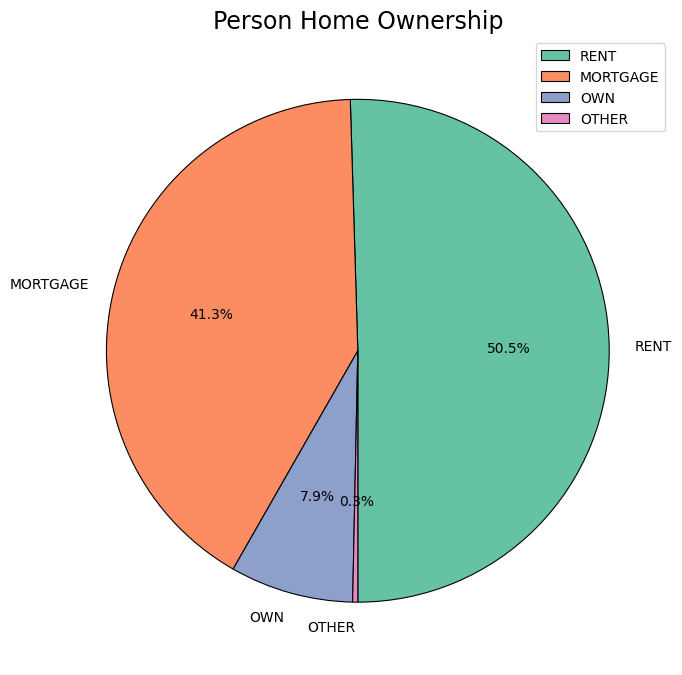

In [18]:
level_counts = credit_risk_df.person_home_ownership.value_counts()
plt.figure(figsize=(7,7))
plt.pie(level_counts.values, labels=level_counts.index,
        autopct='%1.1f%%', startangle=-90, colors=sns.color_palette("Set2"),
        wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
plt.title('Person Home Ownership',fontsize=17)
plt.tight_layout()
plt.legend()
plt.show()

#### **Observation:** Most of the People taking a loan doesnt own their own house

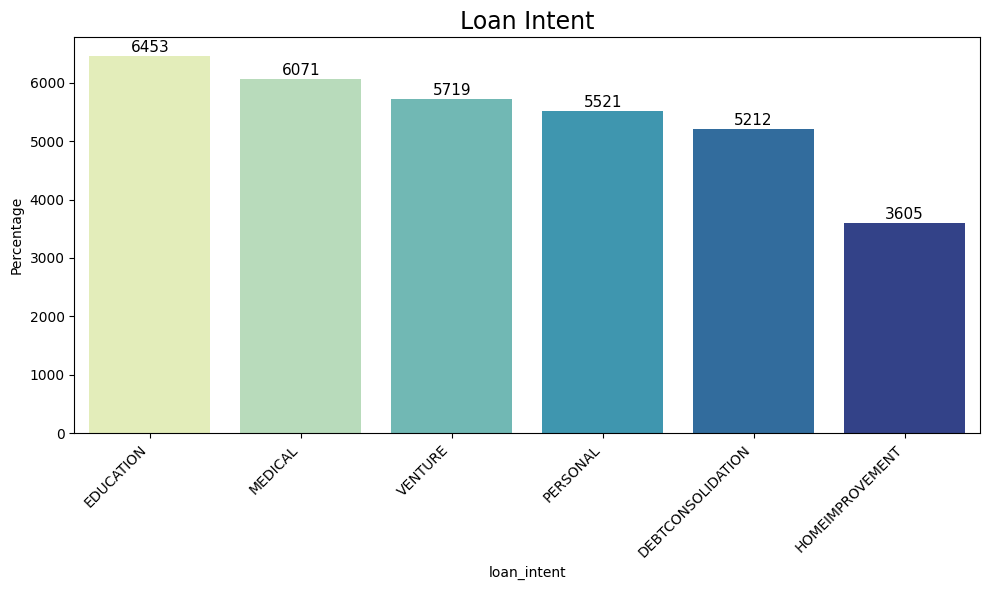

In [19]:
total_counts = credit_risk_df.loan_intent.value_counts().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x="loan_intent",y="count",data=total_counts,hue="loan_intent",palette="YlGnBu")

for i, v in enumerate(total_counts["count"]):
    plt.text(i, v + (max(total_counts["count"])*0.01), f"{v}", ha='center', fontsize=11)

plt.title("Loan Intent",fontsize=17)
plt.xlabel("loan_intent")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **Observation:** Loan Intent is almost equally distributed

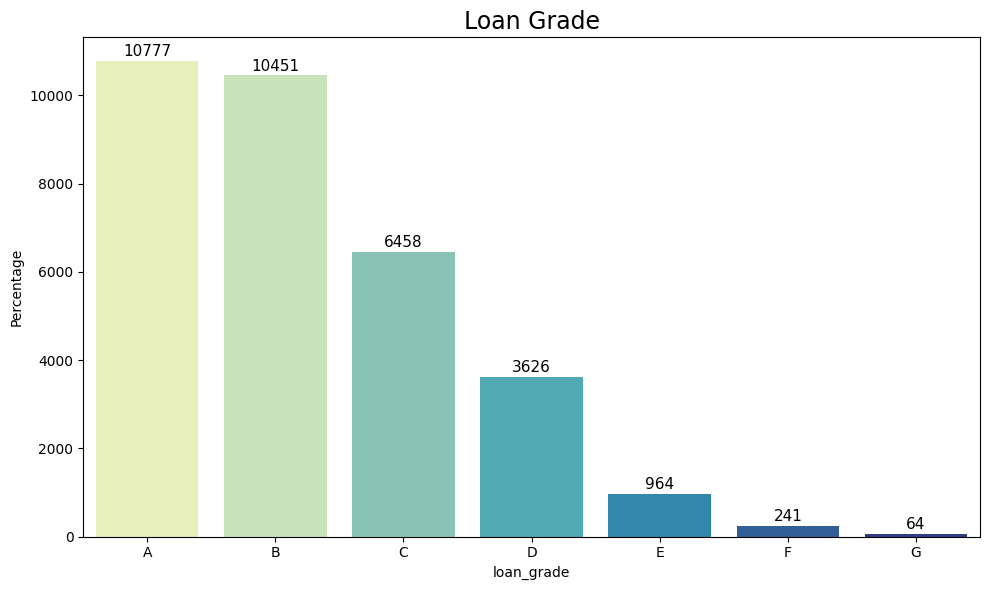

In [20]:
total_counts = credit_risk_df.loan_grade.value_counts().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x="loan_grade",y="count",data=total_counts,hue="loan_grade",palette="YlGnBu")

for i, v in enumerate(total_counts["count"]):
    plt.text(i, v + (max(total_counts["count"])*0.01), f"{v}", ha='center', fontsize=11)

plt.title("Loan Grade",fontsize=17)
plt.xlabel("loan_grade")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

#### **Observation:** Loan Grade A and B comprises of more than half of the samples

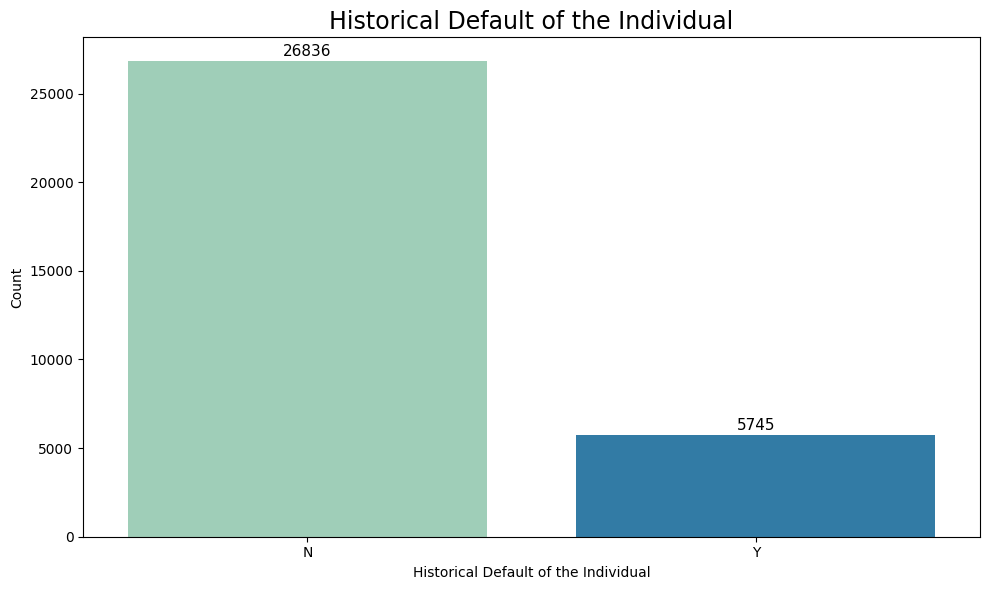

In [21]:
total_counts = credit_risk_df.cb_person_default_on_file.value_counts().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x="cb_person_default_on_file",y="count",data=total_counts,hue="cb_person_default_on_file",palette="YlGnBu")

for i, v in enumerate(total_counts["count"]):
    plt.text(i, v + (max(total_counts["count"])*0.01), f"{v}", ha='center', fontsize=11)

plt.title("Historical Default of the Individual",fontsize=17)
plt.xlabel("Historical Default of the Individual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### **Histogram and Boxplot for all Numerical Features**

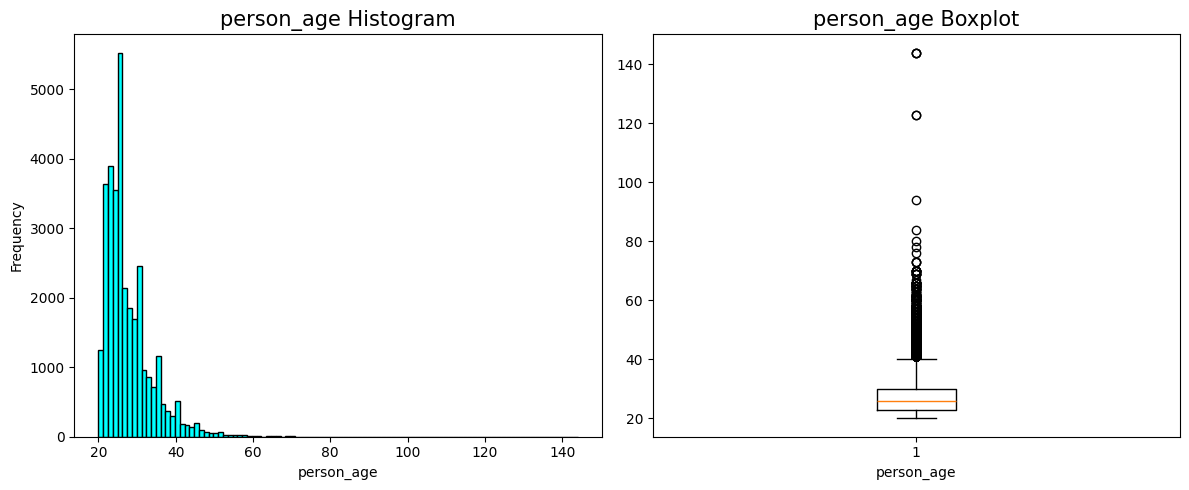

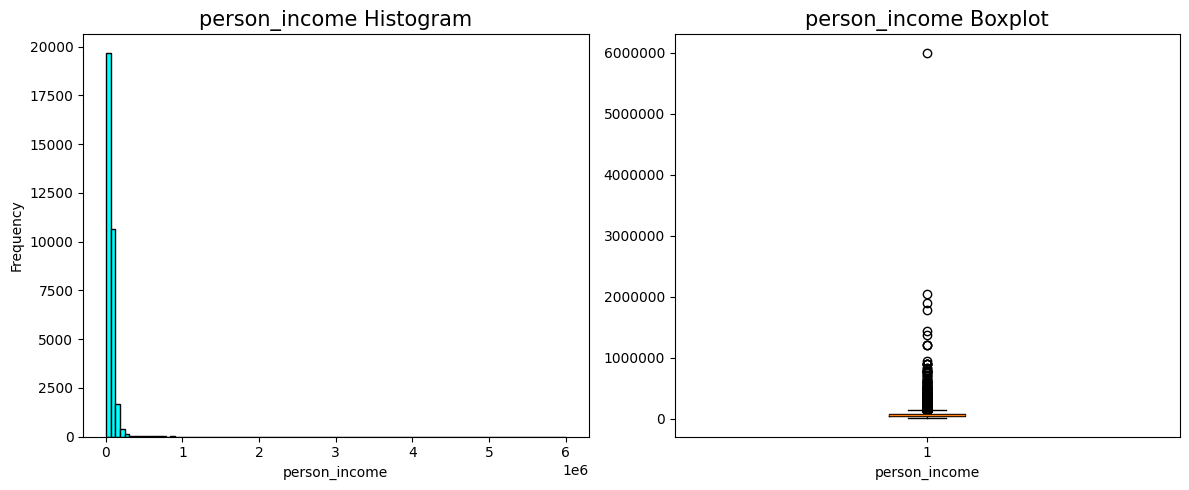

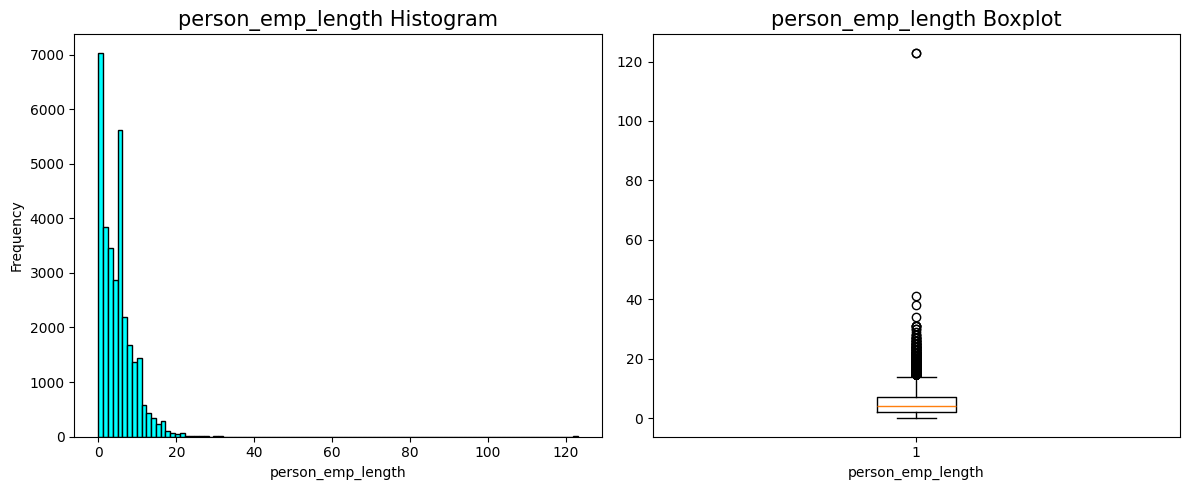

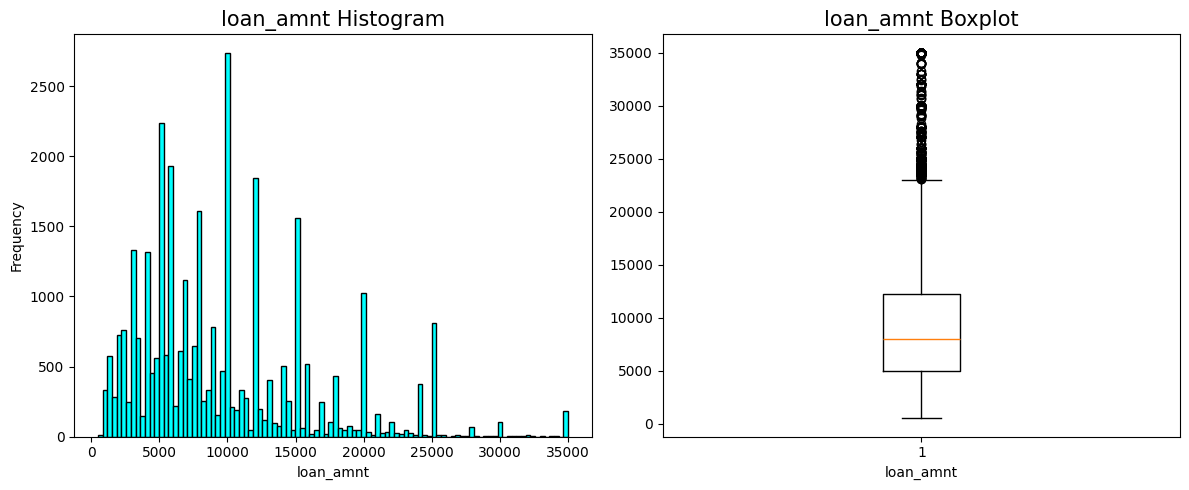

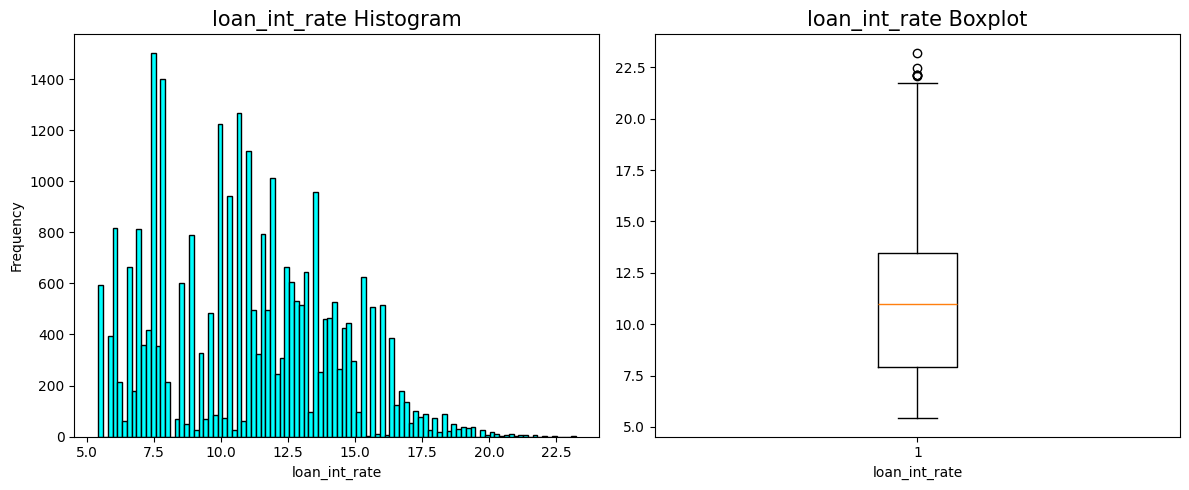

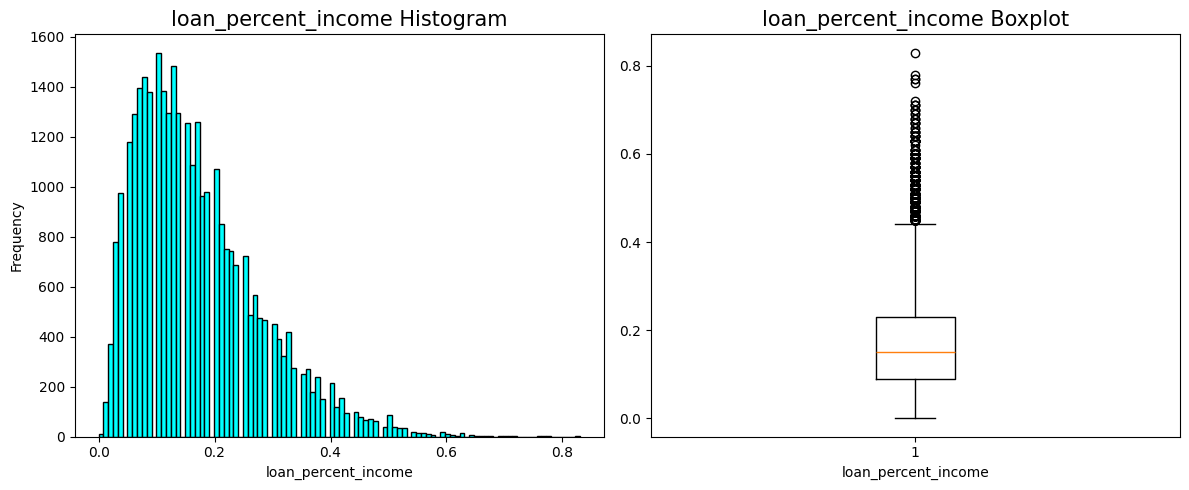

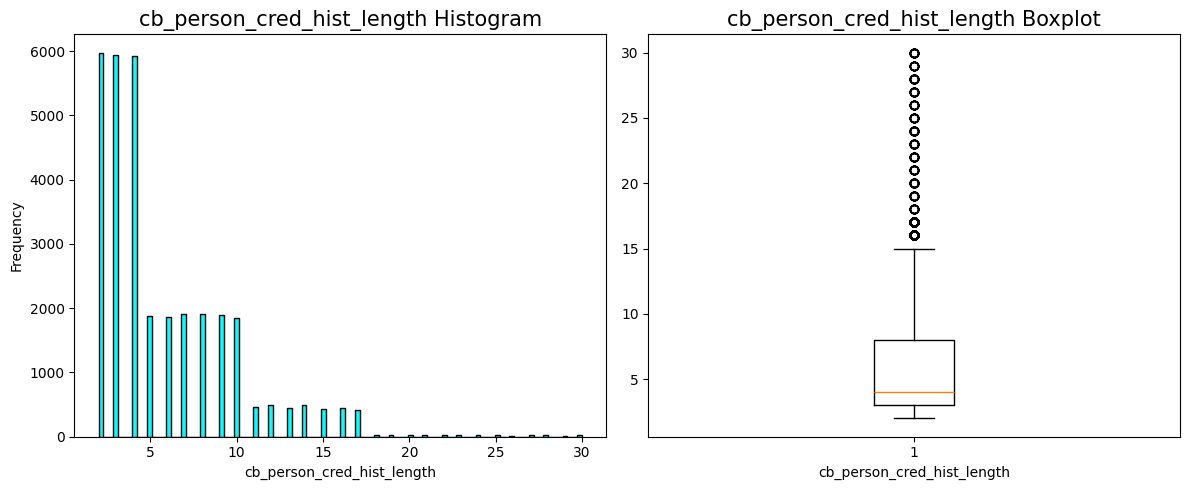

In [22]:
num_features = ["person_age","person_income", "person_emp_length","loan_amnt","loan_int_rate","loan_percent_income","cb_person_cred_hist_length"]

for feature in num_features:
  plt.figure(figsize=(12,5))

  # Histogram
  plt.subplot(1,2,1)
  plt.hist(credit_risk_df[feature].dropna(), bins=100, edgecolor='black',color="cyan")
  plt.title(f"{feature} Histogram",fontsize=15)
  plt.xlabel(feature)
  plt.ylabel("Frequency")

  #Boxplot
  plt.subplot(1,2,2)
  plt.boxplot(credit_risk_df[feature].dropna(),vert=True)
  plt.title(f"{feature} Boxplot",fontsize=15)
  plt.xlabel(feature)
  plt.ticklabel_format(style='plain', axis='y')

  plt.tight_layout()
  plt.show()


In [23]:
credit_risk_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## **Pair Plot for Numerical Features**

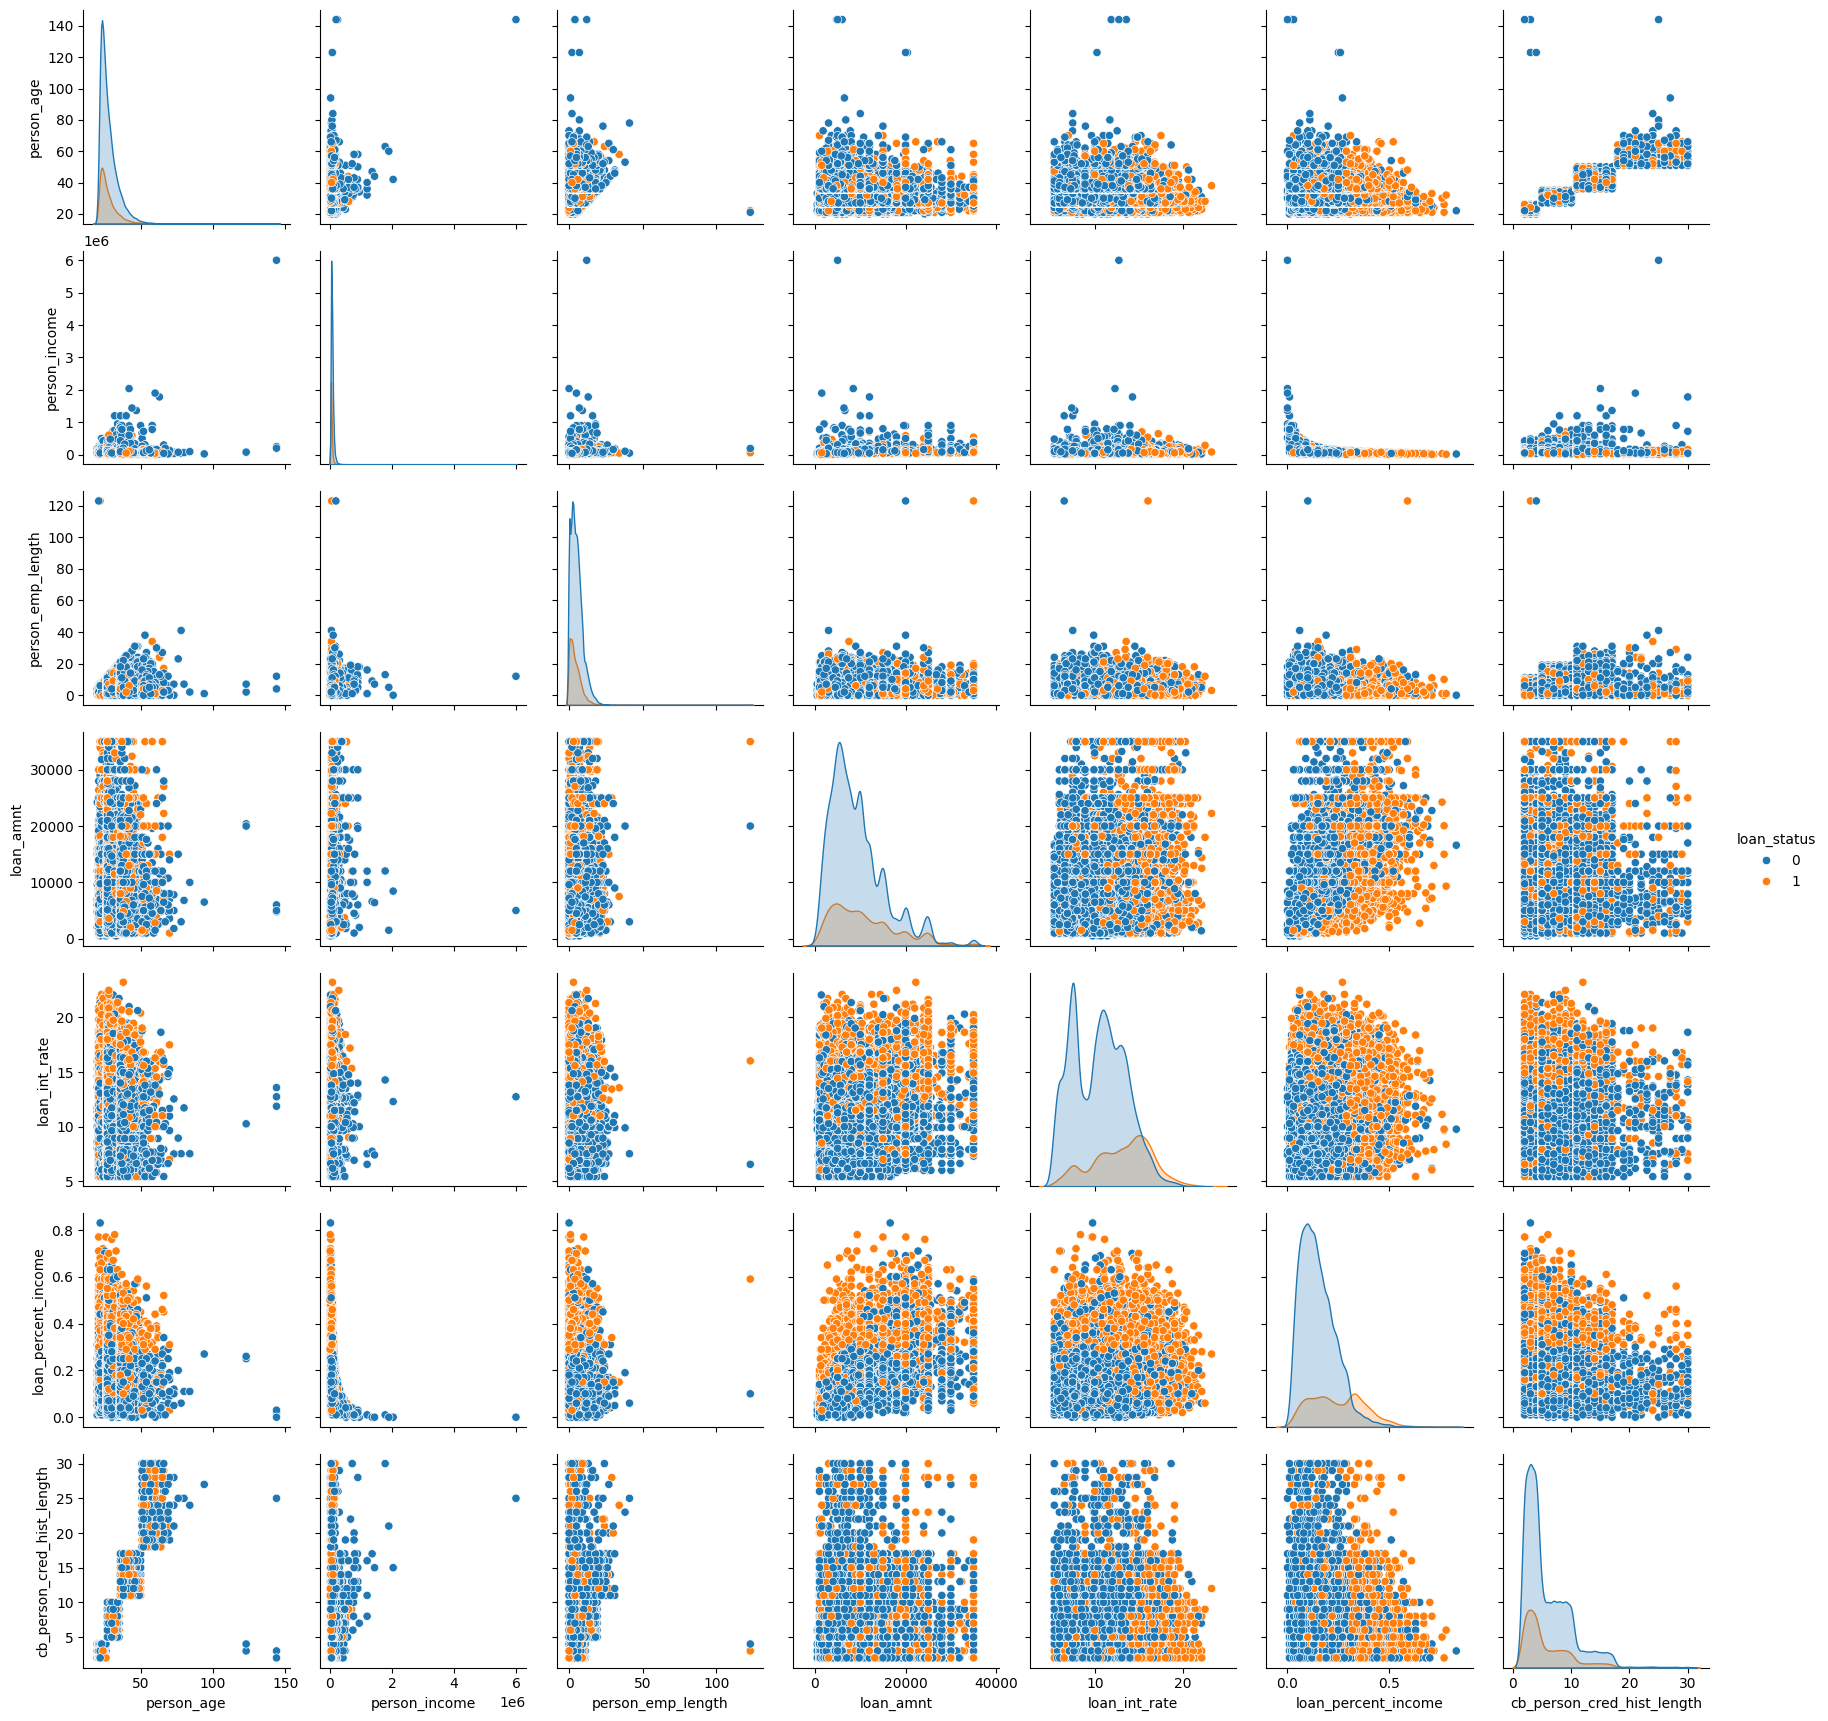

In [24]:
sns.pairplot(credit_risk_df,hue="loan_status")

## **Target Variable Bar Plot (loan_status)**

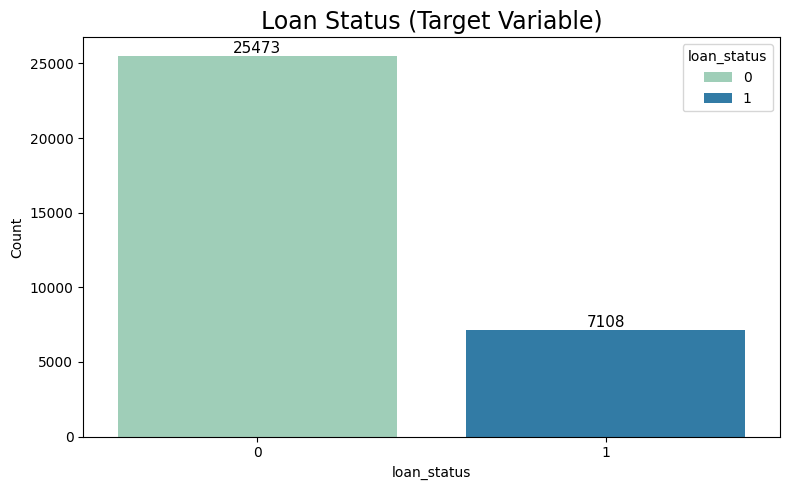

In [25]:
val_counts = credit_risk_df.loan_status.value_counts().reset_index()
val_counts.columns = ["loan_status", "count"]

plt.figure(figsize=(8,5))
sns.barplot(x="loan_status",y="count",data=val_counts,hue="loan_status",palette="YlGnBu")

for i, v in enumerate(val_counts["count"]):
    plt.text(i, v + (max(val_counts["count"])*0.01), f"{v}", ha='center', fontsize=11)

plt.title("Loan Status (Target Variable)",fontsize=17)
plt.xlabel("loan_status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [26]:
credit_risk_df.loan_status.value_counts()


loan_status
0    25473
1     7108
Name: count, dtype: int64

# **Data Preprocessing**

In [27]:
credit_risk_df.shape

(32581, 12)

In [28]:
# Removing unnecessary samples from person_age column(Filter for Age Feature)
credit_risk_df = credit_risk_df.drop(credit_risk_df[credit_risk_df["person_age"]> 90].index, axis=0)

In [29]:
credit_risk_df.shape

(32575, 12)

In [30]:
# Removing unnecessary samples from person_emp column (Filter for Employment Feature)
credit_risk_df = credit_risk_df.drop(credit_risk_df[credit_risk_df["person_emp_length"]>60].index, axis=0)

In [31]:
credit_risk_df.shape

(32573, 12)

In [32]:
# Dealing with Missing Value:
credit_risk_df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3114
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [33]:
# checking the pattern for the missing values column
credit_risk_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32573.000000,3.257300e+04,31678.000000,32573.000000,29459.000000,32573.000000,32573.000000,32573.000000
mean,27.716391,6.587977e+04,4.782183,9588.112854,11.011529,0.218187,0.170199,5.803457
std,6.194205,5.253223e+04,4.034956,6320.323455,3.240497,0.413021,0.106755,4.052234
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,84.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [34]:
# Replacing missing values for loan_int_rate with the median value:
credit_risk_df.fillna({"loan_int_rate":credit_risk_df["loan_int_rate"].median()},inplace=True)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [35]:
# Replacing missing values for person_emp_length with the median value:
credit_risk_df.fillna({"person_emp_length":credit_risk_df["person_emp_length"].median()},inplace=True)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [36]:
credit_risk_df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [37]:
credit_risk_df.shape

(32573, 12)

In [38]:
# Removing the duplicates:
credit_risk_df.duplicated().sum()

np.int64(165)

In [39]:
credit_risk_df.drop_duplicates(inplace=True)
credit_risk_df.shape

(32408, 12)

In [40]:
credit_risk_df.loan_status.value_counts()

loan_status
0    25320
1     7088
Name: count, dtype: int64

### **Feature Engineering**

### Creating New Columns:

In [41]:
# loan-to-income ratio
credit_risk_df['loan_to_income_ratio'] = credit_risk_df['loan_amnt'] / credit_risk_df['person_income']

# loan-to-employment length ratio
credit_risk_df['loan_to_emp_length_ratio'] =  credit_risk_df['person_emp_length']/ credit_risk_df['loan_amnt']

# Create interest rate-to-loan amount ratio
credit_risk_df['int_rate_to_loan_amt_ratio'] = credit_risk_df['loan_int_rate'] / credit_risk_df['loan_amnt']

In [42]:
credit_risk_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,0.005000,0.011140
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,0.000182,0.002340
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,0.000114,0.000435
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,0.000229,0.000408
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525,0.000800,0.002856


In [43]:
credit_risk_df.reset_index(drop=True, inplace=True)
credit_risk_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,0.005000,0.011140
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,0.000182,0.002340
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,0.000114,0.000435
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,0.000229,0.000408
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525,0.000800,0.002856


In [44]:
# Making a copy of the data
raw_data = credit_risk_df.copy()

## **Performing OneHot Encoding & Feature Scaling**

In [45]:
onehot_enco_columns = ["person_home_ownership","loan_intent","loan_grade","cb_person_default_on_file"]
scaler_columns = ["person_age","person_income","person_emp_length","loan_amnt",
                  "loan_int_rate","loan_percent_income","cb_person_cred_hist_length",
                  "loan_to_income_ratio","loan_to_emp_length_ratio","int_rate_to_loan_amt_ratio"]

### Data Splitting

In [46]:
#train test split because we want to fit one-hot encoding and scaling only on train data to avoid data leakage
from sklearn.model_selection import train_test_split

X = credit_risk_df.drop(["loan_status"],axis=1)
y = credit_risk_df["loan_status"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12, stratify=y)

In [48]:
print(X_train.shape,X_test.shape)

(24306, 14) (8102, 14)


In [49]:
X_train.reset_index(drop=True,inplace=True)
X_test.reset_index(drop=True, inplace=True)

In [50]:
X_train.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_to_income_ratio',
       'loan_to_emp_length_ratio', 'int_rate_to_loan_amt_ratio'],
      dtype='str')

### **OneHot-Encoding on Categorical Features**

In [131]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore")
ohe.fit(X_train[onehot_enco_columns])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_categ

In [52]:
ohe.categories_

[array(['MORTGAGE', 'OTHER', 'OWN', 'RENT'], dtype=object),
 array(['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL',
        'PERSONAL', 'VENTURE'], dtype=object),
 array(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype=object),
 array(['N', 'Y'], dtype=object)]

In [53]:
ohe_feature_names = ohe.get_feature_names_out(onehot_enco_columns)

In [54]:
X_train_ohe = ohe.transform(X_train[onehot_enco_columns]).toarray()
X_test_ohe  = ohe.transform(X_test[onehot_enco_columns]).toarray()

In [55]:
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_feature_names, index=X_train.index)
X_test_ohe_df  = pd.DataFrame(X_test_ohe,  columns=ohe_feature_names, index=X_test.index)

In [56]:
# Concatening the OneHot-Encoded Columns with main dataframe and droping the old categorical columns
X_new_train = pd.concat([X_train_ohe_df,X_train],axis=1)
X_new_train = X_new_train.drop(onehot_enco_columns,axis=1)

In [57]:
X_new_train.head()

,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,...,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,22,28000,1.0,12300,6.62,0.44,2,0.439286,0.000081,0.000538
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,25,125000,3.0,10000,5.99,0.08,3,0.080000,0.000300,0.000599
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,26,39600,3.0,4000,5.79,0.10,4,0.101010,0.000750,0.001448
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,27,95000,9.0,25000,10.99,0.26,5,0.263158,0.000360,0.000440
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,25,108000,8.0,15000,6.62,0.14,2,0.138889,0.000533,0.000441


In [58]:
X_new_train.shape

(24306, 29)

In [59]:
X_new_train.columns

Index(['person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_A',
       'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E',
       'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_N',
       'cb_person_default_on_file_Y', 'person_age', 'person_income',
       'person_emp_length', 'loan_amnt', 'loan_int_rate',
       'loan_percent_income', 'cb_person_cred_hist_length',
       'loan_to_income_ratio', 'loan_to_emp_length_ratio',
       'int_rate_to_loan_amt_ratio'],
      dtype='str')

In [60]:
# Same for Test data:
X_new_test = pd.concat([X_test_ohe_df,X_test],axis=1)
X_new_test = X_new_test.drop(onehot_enco_columns,axis=1)

In [61]:
X_new_test.shape

(8102, 29)

### **Scaling on Numerical Features**

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_new_train[scaler_columns])  # Fitting on Training data

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [63]:
X_new_train[scaler_columns] = scaler.transform(X_new_train[scaler_columns])
X_new_test[scaler_columns] = scaler.transform(X_new_test[scaler_columns])

In [64]:
X_new_train.head()

,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,...,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.923620,-0.735034,-0.944106,0.435448,-1.424051,2.528280,-0.939507,2.511303,-0.649569,-0.723818
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.440142,1.149741,-0.440657,0.070026,-1.628613,-0.843037,-0.693003,-0.844256,-0.444099,-0.691088
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.278982,-0.509639,-0.440657,-0.883247,-1.693553,-0.655742,-0.446498,-0.648031,-0.021319,-0.234245
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.117823,0.566821,1.069688,2.453211,-0.005111,0.842621,-0.199994,0.866352,-0.387728,-0.776911
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.440142,0.819419,0.817964,0.864421,-1.424051,-0.281151,-0.939507,-0.294261,-0.224880,-0.775978


In [65]:
X_new_test.head()

,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,...,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.278982,0.197638,0.314515,-0.247732,0.803393,-0.562094,-0.446498,-0.608310,-0.021319,-0.106372
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.493772,-0.836074,3.335206,-0.406610,-1.615625,1.310860,1.525535,1.275981,1.689934,-0.549793
2,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.923620,-0.608735,-0.692381,-0.724368,1.910622,-0.281151,-0.939507,-0.237863,-0.350148,0.805161
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.654931,0.663896,4.342103,2.453211,1.283950,0.748974,1.772039,0.743557,0.100818,-0.691411
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.010293,-0.035530,-0.692381,-0.247732,-1.329888,-0.374799,-0.199994,-0.423977,-0.491074,-0.548543


## **Applying Machine Learning Classification Models**

### **1. Logistic Regression Classifier**

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report,f1_score

In [67]:
logit = LogisticRegression()
logit.fit(X_new_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [68]:
logit.score(X_new_train,y_train)

0.8744342960585864

In [69]:
logit_pred = logit.predict(X_new_test)

In [70]:
logit_pred

array([0, 0, 1, ..., 0, 1, 0], shape=(8102,))

In [71]:
print(classification_report(y_test,logit_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      6330
           1       0.78      0.57      0.66      1772

    accuracy                           0.87      8102
   macro avg       0.83      0.76      0.79      8102
weighted avg       0.86      0.87      0.86      8102



In [72]:
accuracy_score(y_test,logit_pred)

0.870278943470748

In [73]:
precision_score(y_test,logit_pred)

0.7792408985282726

In [74]:
recall_score(y_test,logit_pred)

0.5677200902934537

In [75]:
# Calculate confusion matrix to get TN and FP for specificity
tn, fp, fn, tp = confusion_matrix(y_test, logit_pred).ravel()
specificity = tn / (tn + fp)
print(specificity)

0.9549763033175356


### **2. Random Forest Classifier**

In [76]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300,max_depth=None, random_state=42, class_weight="balanced")

In [77]:
rf.fit(X_new_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [78]:
rf.score(X_new_train,y_train)

1.0

In [79]:
rf_pred = rf.predict(X_new_test)
rf_pred

array([0, 0, 1, ..., 0, 1, 0], shape=(8102,))

In [80]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      6330
           1       0.98      0.72      0.83      1772

    accuracy                           0.93      8102
   macro avg       0.95      0.86      0.89      8102
weighted avg       0.94      0.93      0.93      8102



In [81]:
accuracy_score(y_test,rf_pred)

0.9338434954332263

In [82]:
precision_score(y_test,rf_pred)

0.9753846153846154

In [83]:
recall_score(y_test,rf_pred)

0.7155756207674944

In [84]:
# Calculate confusion matrix to get TN and FP for specificity
tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()
specificity = tn / (tn + fp)
print(specificity)

0.9949447077409163


### **3. XGBoost Classifier**

In [85]:
from xgboost import XGBClassifier

In [86]:
# For handling imabalance data:
class_counts = y_train.value_counts()
neg, pos = class_counts[0], class_counts[1]
scale_pos_weight = neg / pos

In [87]:
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight)

In [88]:
xgb.fit(X_new_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [89]:
xgb.score(X_new_train,y_train)

0.9743684686908582

In [90]:
xgb_pred = xgb.predict(X_new_test)
xgb_pred

array([0, 0, 1, ..., 0, 1, 0], shape=(8102,))

In [91]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      6330
           1       0.84      0.80      0.82      1772

    accuracy                           0.92      8102
   macro avg       0.89      0.88      0.89      8102
weighted avg       0.92      0.92      0.92      8102



In [92]:
accuracy_score(y_test,xgb_pred)

0.9231054060725746

In [93]:
precision_score(y_test,xgb_pred)

0.8397397989355411

In [94]:
recall_score(y_test,xgb_pred)

0.801354401805869

In [95]:
# Calculate confusion matrix to get TN and FP for specificity
tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred).ravel()
specificity = tn / (tn + fp)
print(specificity)

0.9571879936808847


### **4. CatBoost Classifier Model**

In [96]:
from catboost import CatBoostClassifier

In [97]:
# Class Weights (for handling imabalance data):
class_counts = y_train.value_counts()
neg, pos = class_counts[0], class_counts[1]
class_weights = [1, neg/pos]

In [98]:
# Model training
cat = CatBoostClassifier(class_weights=class_weights,verbose=0)
cat.fit(X_new_train,y_train)

CatBoostClassifier(class_weights=[1, np.float64(3.572234762979684)], verbose=0)

In [99]:
print(cat.score(X_new_train,y_train))

0.9538385583806468


In [100]:
cat_pred = cat.predict(X_new_test)
cat_pred

array([0, 0, 1, ..., 0, 1, 0], shape=(8102,))

In [101]:
print(classification_report(y_test,cat_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      6330
           1       0.85      0.79      0.82      1772

    accuracy                           0.92      8102
   macro avg       0.89      0.88      0.88      8102
weighted avg       0.92      0.92      0.92      8102



In [102]:
accuracy_score(y_test,cat_pred)

0.9226117008146136

In [103]:
precision_score(y_test,cat_pred)

0.8455039227519614

In [104]:
recall_score(y_test,cat_pred)

0.7906320541760722

In [105]:
# Calculate confusion matrix to get TN and FP for specificity
tn, fp, fn, tp = confusion_matrix(y_test, cat_pred).ravel()
specificity = tn / (tn + fp)
print(specificity)

0.9595576619273302


# **Model Comparison**

In [106]:
results = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "CatBoost"],
    "Accuracy": [
        accuracy_score(y_test,logit_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred),
        accuracy_score(y_test,cat_pred)
    ],
    "Precision": [
        precision_score(y_test,logit_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred),
        precision_score(y_test,cat_pred)
    ],
    "Recall": [
        recall_score(y_test,logit_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred),
        recall_score(y_test,cat_pred)
    ],
    "F1 Score": [
        f1_score(y_test,logit_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred),
        f1_score(y_test,cat_pred)
    ]
}

In [107]:
df_results = pd.DataFrame(results)
df_results.index = df_results.index + 1

In [109]:
df_styled = (
    df_results.style
        .set_table_styles([
            {"selector": "table", "props": [
                ("font-size", "18px"),
                ("width", "100%"),
                ("border-collapse", "collapse")
            ]},
            {"selector": "th", "props": [
                ("font-size", "20px"),
                ("text-align", "center"),
                ("padding", "12px")
            ]},
            {"selector": "td", "props": [
                ("text-align", "center"),
                ("padding", "15px"),
                ("font-size", "18px")
            ]}
        ])
        .set_properties(**{
            "line-height": "2.5",
            "min-width": "150px"
        })
        .background_gradient(cmap="Blues")
)

df_styled


,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.870279,0.779241,0.567720,0.656872
2,Random Forest,0.933843,0.975385,0.715576,0.825521
3,XGBoost,0.923105,0.839740,0.801354,0.820098
4,CatBoost,0.922612,0.845504,0.790632,0.817148


In [110]:
# Saving the comparison table
df_results.to_csv("model_comparison.csv",index=False)

# **BEST MODEL - XGBoost Classifier**

### **1. Hyperparameter Tuning on XGBoost**

In [114]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Computing imbalance ratio for scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

print("Negative class count:", neg_count)
print("Positive class count:", pos_count)
print("scale_pos_weight:", scale_pos_weight_value)

Negative class count: 18990
Positive class count: 5316
scale_pos_weight: 3.572234762979684


In [115]:
# Picking the smaller grid so it runs in reasonable time
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="recall",   # important for credit default detection
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_new_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.05, 0.1], 'max_depth': [4, 6], 'n_estimators': [200, 300], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

### Best Paramters for XGBoost

In [116]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_)

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV Recall: 0.7938299473288186


In [117]:
# Using the best parameters
xgb_tuned = grid_search.best_estimator_

xgb_tuned_pred = xgb_tuned.predict(X_new_test)
xgb_tuned_prob = xgb_tuned.predict_proba(X_new_test)[:, 1]

print(classification_report(y_test, xgb_tuned_pred))

print("Accuracy :", accuracy_score(y_test, xgb_tuned_pred))
print("Precision:", precision_score(y_test, xgb_tuned_pred))
print("Recall   :", recall_score(y_test, xgb_tuned_pred))
print("F1 Score :", f1_score(y_test, xgb_tuned_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_tuned_prob))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      6330
           1       0.78      0.80      0.79      1772

    accuracy                           0.91      8102
   macro avg       0.86      0.87      0.86      8102
weighted avg       0.91      0.91      0.91      8102

Accuracy : 0.9058257220439397
Precision: 0.7776554760594386
Recall   : 0.7974040632054176
F1 Score : 0.7874059626636947
ROC-AUC  : 0.9455061889529598


## **2. Cross-Validation on XGBoost**

In [118]:
from sklearn.model_selection import cross_val_score

cv_recall_scores = cross_val_score(
    xgb_tuned,
    X_new_train,
    y_train,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

cv_f1_scores = cross_val_score(
    xgb_tuned,
    X_new_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Recall CV Scores:", cv_recall_scores)
print("Mean Recall CV  :", cv_recall_scores.mean())

print("F1 CV Scores    :", cv_f1_scores)
print("Mean F1 CV      :", cv_f1_scores.mean())

Recall CV Scores: [0.80545113 0.80714958 0.7939793  0.80338664 0.76105362]
Mean Recall CV  : 0.7942040543503632
F1 CV Scores    : [0.79795158 0.7970274  0.78657968 0.78492647 0.7786333 ]
Mean F1 CV      : 0.7890236882922964


#### Hyperparameter tuning was performed on the XGBoost model using GridSearchCV. However, after evaluating the tuned model on the test set, the baseline XGBoost model demonstrated slightly better performance in terms of overall metrics such as accuracy, precision, and F1 score while maintaining similar recall.

#### Since the primary objective is to maintain strong detection of default borrowers while preserving overall model performance, the original XGBoost model was retained as the final model.

#### Therefore, the baseline XGBoost model is used for final evaluation, feature importance analysis, SHAP explainability, ROC curve analysis, and model deployment.

## **Feature Importance Analysis (XGBoost)**

<Figure size 1000x800 with 0 Axes>

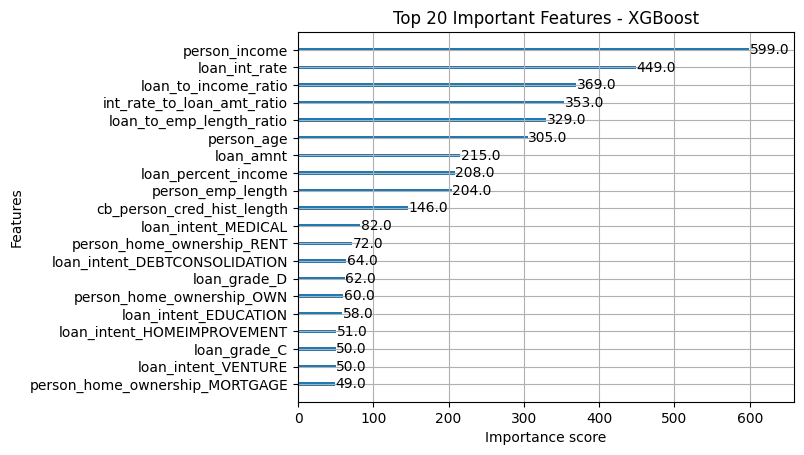

In [111]:
# Feature Importance for XGBoost Classifier:
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(xgb, max_num_features=20)
plt.title("Top 20 Important Features - XGBoost")
plt.show()

## SHAP Explainability for Best XGBoost Model

In [123]:
import shap
import matplotlib.pyplot as plt

# Using a sample to make SHAP faster
X_shap_sample = X_new_test.sample(n=min(500, len(X_new_test)), random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap_sample)

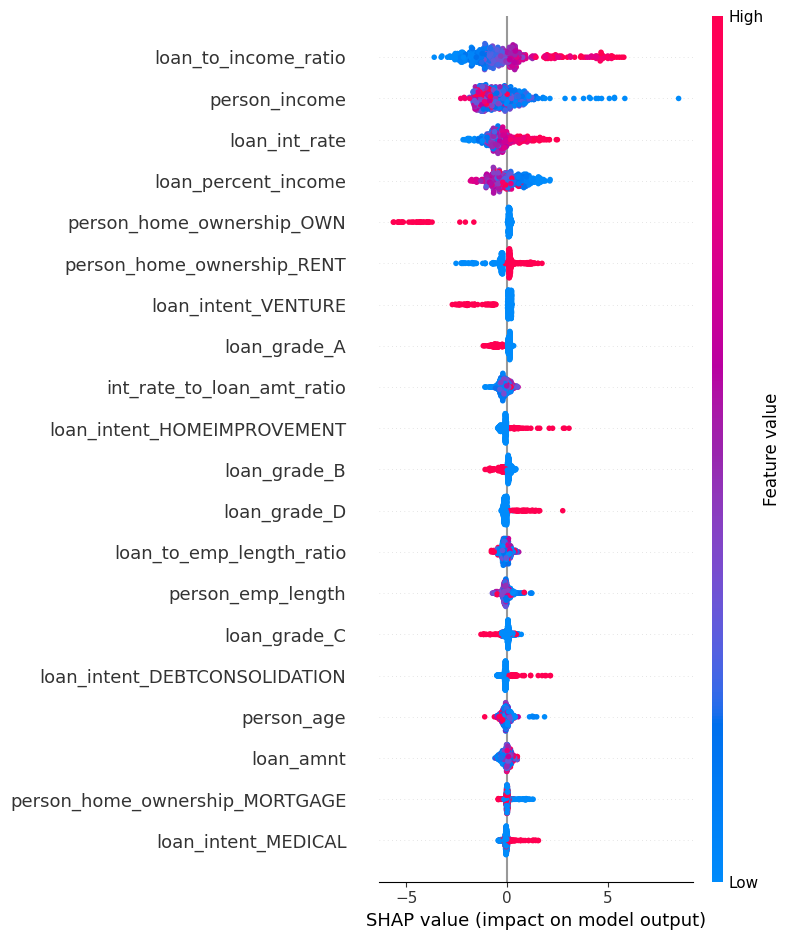

In [124]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.tight_layout()
plt.show()

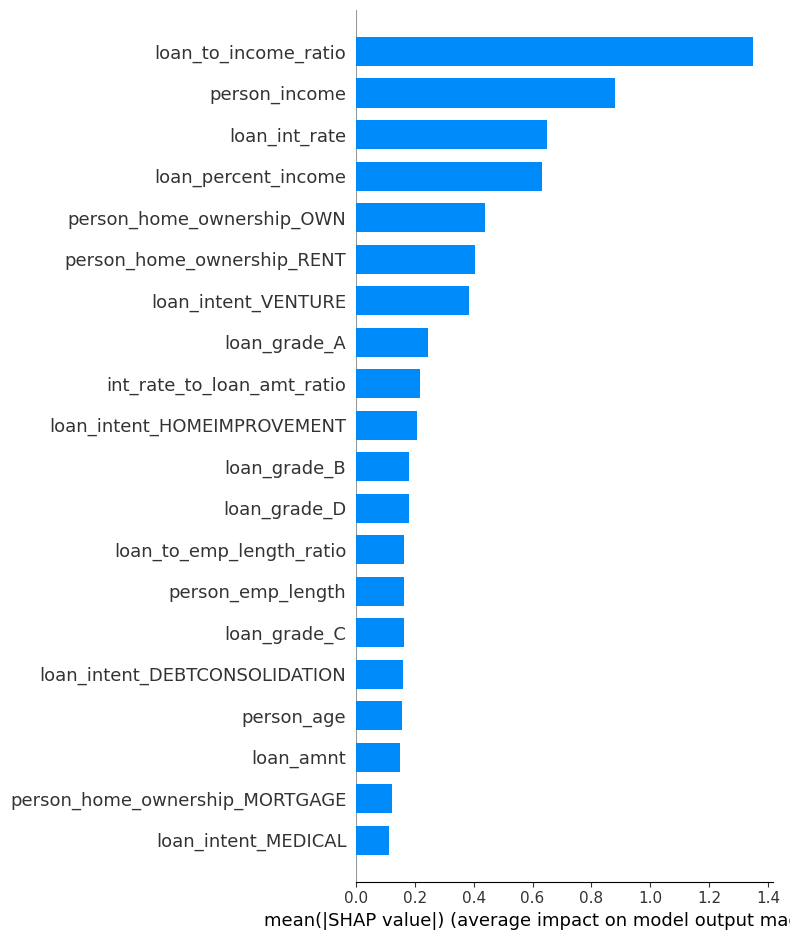

In [125]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

#### SHAP analysis was used to interpret the contribution of features toward default prediction. It helps explain the model beyond standard feature importance by showing both feature impact and direction.

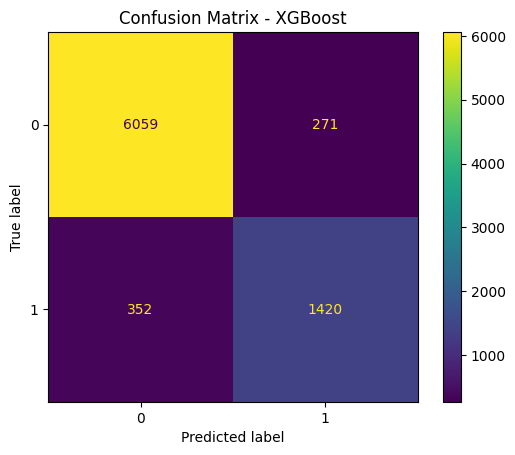

In [112]:
# Plotting Confusion Matrix for XGBoost Classifier:

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred)
plt.title("Confusion Matrix - XGBoost")
plt.show()

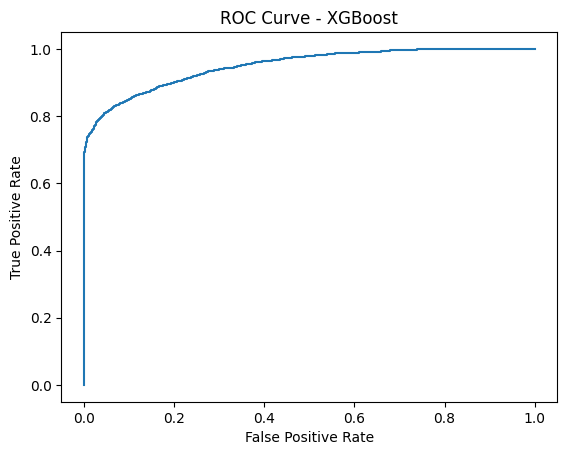

AUC Score: 0.9494419065755174


In [113]:
# Plotting the ROC Curve and AUC:

from sklearn.metrics import roc_curve, roc_auc_score

xgb_prob = xgb.predict_proba(X_new_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, xgb_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC Score:", roc_auc_score(y_test, xgb_prob))


## **Saving Final Model and Preprocessing Artifacts**

In [126]:
import joblib
import os

# Creating a folder:
os.makedirs("models", exist_ok=True)

In [127]:
joblib.dump(xgb, "models/xgb_credit_risk_model.pkl")
joblib.dump(ohe, "models/onehot_encoder.pkl")
joblib.dump(scaler, "models/standard_scaler.pkl")
joblib.dump(onehot_enco_columns, "models/onehot_columns.pkl")
joblib.dump(scaler_columns, "models/scaler_columns.pkl")
joblib.dump(X_new_train.columns.tolist(), "models/final_feature_order.pkl")

print("Model and preprocessing artifacts saved successfully.")

Model and preprocessing artifacts saved successfully.


#### ***Example Prediction using Final Model***

In [128]:
sample_input = X_new_test.iloc[[0]]   # keep double brackets to preserve DataFrame shape
sample_actual = y_test.iloc[0]

sample_pred = xgb_tuned.predict(sample_input)[0]
sample_prob = xgb_tuned.predict_proba(sample_input)[0][1]

print("Actual Class         :", sample_actual)
print("Predicted Class      :", sample_pred)
print("Default Probability  :", round(sample_prob, 4))

if sample_pred == 1:
    print("Interpretation       : High-risk borrower (likely default)")
else:
    print("Interpretation       : Low-risk borrower (likely non-default)")

Actual Class         : 1
Predicted Class      : 0
Default Probability  : 0.2289
Interpretation       : Low-risk borrower (likely non-default)


In [130]:
# For prediction on few rows of data:
sample_batch = X_new_test.iloc[:5]
batch_preds = xgb_tuned.predict(sample_batch)
batch_probs = xgb_tuned.predict_proba(sample_batch)[:, 1]

prediction_df = sample_batch.copy()
prediction_df["predicted_class"] = batch_preds
prediction_df["default_probability"] = batch_probs

prediction_df.head()

,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,...,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio,predicted_class,default_probability
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.314515,-0.247732,0.803393,-0.562094,-0.446498,-0.608310,-0.021319,-0.106372,0,0.228891
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,3.335206,-0.406610,-1.615625,1.310860,1.525535,1.275981,1.689934,-0.549793,0,0.004720
2,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.692381,-0.724368,1.910622,-0.281151,-0.939507,-0.237863,-0.350148,0.805161,1,0.994898
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.342103,2.453211,1.283950,0.748974,1.772039,0.743557,0.100818,-0.691411,0,0.016029
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.692381,-0.247732,-1.329888,-0.374799,-0.199994,-0.423977,-0.491074,-0.548543,0,0.100531
